# Практична робота 4.13. Практичне використання репозиторіїв аналітичних моделей
## Частина 1 (індивідуальна): Transfer learning з репозиторію моделей

**Номер за журналом:** 7 · Частина 2 (групова, RL-агент DQN) міститься у ноутбуці `4.13_2_rl_dqn.ipynb`.

**Мета:** навчитися повторно використовувати попередньо навчену модель з публічного репозиторію моделей: перевірити цілісність, прочитати model card, виконати feature extraction і fine-tuning. Оцінити, коли transfer learning дає перевагу над навчанням «з нуля».

**Про джерело моделі.** Завдання рекомендує TensorFlow Hub або PyTorch Model Zoo. Вони в середовищі виконання заблоковані, тому ваги MobileNetV2 (ImageNet) завантажено з GitHub-релізу автора Keras-реалізації. Це той самий файл, який підвантажує `keras.applications.MobileNetV2(weights="imagenet")`, тобто модель з репозиторію Keras Applications. Процедура (фіксоване джерело → перевірка SHA-256 → model card → адаптація) однакова для будь-якого репозиторію.

In [1]:
import os, json, time, gzip, hashlib, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="whitegrid")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

SEED = 42
keras.utils.set_random_seed(SEED)
print("TensorFlow", tf.__version__)

I0000 00:00:1790330639.801768   30295 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790330641.578824   30295 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


# Частина 1. Transfer learning з репозиторію моделей

**Прикладна задача.** Автоматична класифікація предметів речового забезпечення за фото на складі: 10 категорій (футболки, штани, светри, куртки, взуття, сумки тощо). Розмічених фото **мало**, від 10 до 100 на категорію. Розмітка коштує часу фахівців, тому питання таке: чи можна отримати прийнятну точність, використавши модель, яку вже навчили на мільйонах зображень?

**Дані.** Відкритий набір **Fashion-MNIST** (Zalando Research, MIT License): зображення 28×28 у відтінках сірого, 10 класів. Використовується офіційна частина `t10k` (10 000 зображень), завантажена з репозиторію проєкту на GitHub.

**Модель з репозиторію.** **MobileNetV2** (α = 1.0, вхід 96×96, без класифікаційної голови), навчена на ImageNet (1.28 млн зображень, 1000 класів). Ваги беруться з GitHub-релізу автора Keras-реалізації. Це той самий файл, який використовує `keras.applications.MobileNetV2`.

## 1.1. Завантаження даних

(10000, 28, 28) | зображень у класах: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
test / val / pool: 2000 500 7500


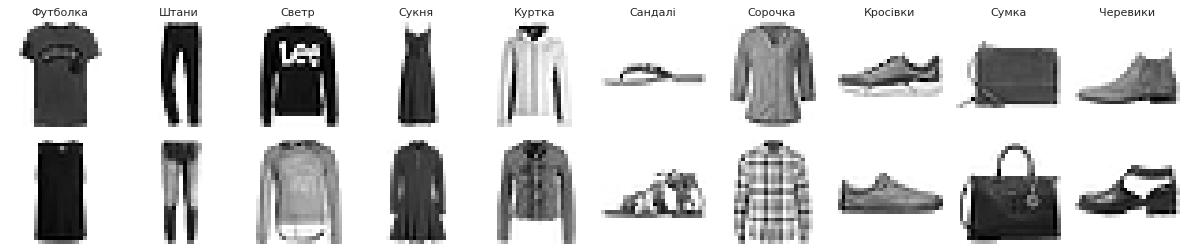

In [2]:
os.makedirs("data", exist_ok=True)
FM = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
for f in ["t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]:
    if not os.path.exists(f"data/{f}"):
        urllib.request.urlretrieve(FM + f, f"data/{f}")
X = np.frombuffer(gzip.open("data/t10k-images-idx3-ubyte.gz").read(), np.uint8, offset=16).reshape(-1, 28, 28)
y = np.frombuffer(gzip.open("data/t10k-labels-idx1-ubyte.gz").read(), np.uint8, offset=8).astype(int)
CLASSES = ["Футболка", "Штани", "Светр", "Сукня", "Куртка", "Сандалі", "Сорочка", "Кросівки", "Сумка", "Черевики"]
print(X.shape, "| зображень у класах:", np.bincount(y))

# фіксований протокол: test 2000, validation 500, решта (7500) — пул, з якого беремо малі розмічені вибірки
perm = np.random.default_rng(SEED).permutation(len(X))
idx_test, idx_val, idx_pool = perm[:2000], perm[2000:2500], perm[2500:]
print("test / val / pool:", len(idx_test), len(idx_val), len(idx_pool))

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for c in range(10):
    for r, i in enumerate(np.where(y == c)[0][:2]):
        axes[r, c].imshow(X[i], cmap="gray_r"); axes[r, c].axis("off")
    axes[0, c].set_title(CLASSES[c], fontsize=10)
plt.tight_layout(); plt.show()

## 1.2. Отримання моделі з репозиторію: цілісність і model card
Модель зі стороннього джерела — це код і ваги, яким ми довіряємо. Перед використанням потрібно:
1. завантажити файл із **зафіксованого** джерела (конкретний реліз, а не «останню версію»);
2. перевірити **контрольну суму SHA-256**: файл не пошкоджений і не підмінений;
3. записати **model card**: звідки модель, на чому навчена, який вхідний формат, які обмеження.

In [3]:
REPO = "model_repo"
os.makedirs(REPO, exist_ok=True)
WEIGHTS_URL = ("https://github.com/JonathanCMitchell/mobilenet_v2_keras/releases/download/v1.1/"
               "mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5")
WEIGHTS = f"{REPO}/mobilenet_v2_1.0_96_imagenet_no_top.h5"
EXPECTED_SHA256 = "8b474d1d1d281884fdbae8a4ff671a6c8edbbb62605cfbf6c7e827424bf91739"

if not os.path.exists(WEIGHTS):
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS)
sha = hashlib.sha256(open(WEIGHTS, "rb").read()).hexdigest()
print(f"Файл: {WEIGHTS} ({os.path.getsize(WEIGHTS) / 1e6:.1f} MB)")
print("SHA-256 збігається:", sha == EXPECTED_SHA256)
assert sha == EXPECTED_SHA256, "контрольна сума не збігається — модель не використовувати"

card = {
    "name": "MobileNetV2 (alpha=1.0, 96x96, no top)",
    "source": WEIGHTS_URL,
    "sha256": sha,
    "pretrained_on": "ImageNet ILSVRC-2012 (1.28M images, 1000 classes)",
    "architecture": "Sandler et al., 2018. MobileNetV2: Inverted Residuals and Linear Bottlenecks",
    "input": "RGB float32 (96, 96, 3), preprocess: keras.applications.mobilenet_v2.preprocess_input (scale to [-1, 1])",
    "output": "feature map (3, 3, 1280); after GlobalAveragePooling — 1280-d vector",
    "license": "Apache 2.0 (Keras Applications)",
    "limitations": "natural colour photos; our data are 28x28 grayscale -> domain shift (upscaling, channel replication)",
}
json.dump(card, open(f"{REPO}/model_card.json", "w", encoding="utf-8"), indent=2, ensure_ascii=False)
base = keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights=WEIGHTS)
print(f"Модель завантажено: {base.count_params():,} параметрів, {len(base.layers)} шарів")

Файл: model_repo/mobilenet_v2_1.0_96_imagenet_no_top.h5 (9.4 MB)
SHA-256 збігається: True


Модель завантажено: 2,257,984 параметрів, 154 шарів


## 1.3. Узгодження вхідного формату
Модель очікує кольорові зображення 96×96 з нормалізацією в [−1, 1]. Наші дані мають розмір 28×28 і один канал, тому виконуємо: збільшення до 96×96, дублювання каналу в RGB і `preprocess_input`. Невідповідність формату — найчастіша причина «зламаного» transfer learning.

In [4]:
def to_model_input(imgs):
    x = tf.image.resize(imgs[..., None].astype("float32"), (96, 96))
    x = tf.repeat(x, 3, axis=-1)
    return keras.applications.mobilenet_v2.preprocess_input(x).numpy()

base.trainable = False
extractor = keras.Sequential([base, layers.GlobalAveragePooling2D()], name="feature_extractor")
t0 = time.time()
EMB = {name: extractor.predict(to_model_input(X[idx]), batch_size=128, verbose=0)
       for name, idx in [("test", idx_test), ("val", idx_val), ("pool", idx_pool)]}
print(f"Ознаки (1280-вимірні) обчислено для 10 000 зображень за {time.time() - t0:.0f} s")

Ознаки (1280-вимірні) обчислено для 10 000 зображень за 29 s


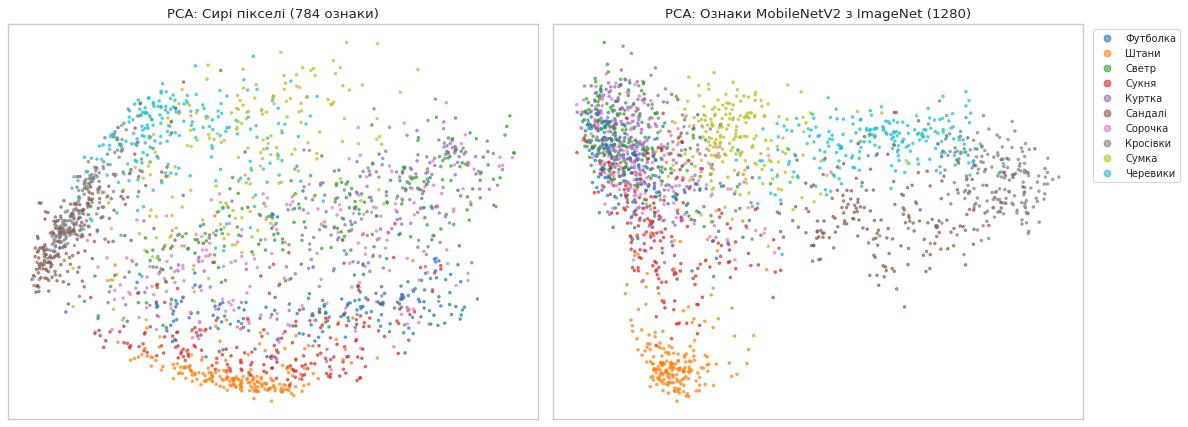

In [5]:
# Чи несуть ImageNet-ознаки інформацію про наші класи? Проєкція на 2 головні компоненти: пікселі vs ознаки моделі
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, data, title in [(axes[0], X[idx_test].reshape(len(idx_test), -1) / 255.0, "Сирі пікселі (784 ознаки)"),
                        (axes[1], EMB["test"], "Ознаки MobileNetV2 з ImageNet (1280)")]:
    p = PCA(2, random_state=SEED).fit_transform(data)
    sc = ax.scatter(p[:, 0], p[:, 1], c=y[idx_test], cmap="tab10", s=5, alpha=0.6)
    ax.set_title(f"PCA: {title}"); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(sc.legend_elements()[0], CLASSES, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 1.4. Три стратегії та експеримент з обсягом розмітки
| Стратегія | Що навчається | Вартість |
|---|---|---|
| **Scratch** | невелика CNN на зображеннях 28×28 з випадкових ваг | низька |
| **Feature extraction** | лише нова голова (Dropout + Dense 10) на заморожених ознаках MobileNetV2 | дуже низька: ознаки обчислюються один раз |
| **Fine-tuning** | голова з feature extraction і верхні 30 шарів MobileNetV2, learning rate 1e-5; BatchNorm заморожений | висока: прямий і зворотний прохід через мережу |

Бюджети розмітки: 10, 25, 50 і 100 фото на клас, по 3 повтори з різними випадковими вибірками. Validation (500) використовується тільки для ранньої зупинки, test (2000) лише для оцінки.

In [6]:
def early(p): return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=p, restore_best_weights=True)]
def compile_(m, lr):
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"]); return m

def scratch_cnn():
    return compile_(keras.Sequential([
        keras.Input((28, 28, 1)),
        layers.Conv2D(32, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
        layers.Flatten(), layers.Dropout(0.4), layers.Dense(64, activation="relu"), layers.Dense(10, activation="softmax")]), 1e-3)

def new_head():
    return compile_(keras.Sequential([keras.Input((1280,)), layers.Dropout(0.3), layers.Dense(10, activation="softmax")]), 1e-3)

def fine_tune(head, Xtr, ytr):
    b = keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights=WEIGHTS)
    b.trainable = True
    for layer in b.layers[:-30]:
        layer.trainable = False
    for layer in b.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    inp = keras.Input((96, 96, 3))
    out = head(layers.GlobalAveragePooling2D()(b(inp, training=False)))
    m = compile_(keras.Model(inp, out), 1e-5)
    m.fit(to_model_input(Xtr), ytr, validation_data=(Xva_m, y[idx_val]), epochs=15, batch_size=16, verbose=0, callbacks=early(4))
    return m

px = lambda idx: (X[idx] / 255.0)[..., None]
Xva_m, Xte_m = to_model_input(X[idx_val]), to_model_input(X[idx_test])

def sample(k, rep):
    r = np.random.default_rng(1000 * k + rep)
    return np.concatenate([r.choice(np.where(y[idx_pool] == c)[0], k, replace=False) for c in range(10)])

rows, keep = [], {}
for k in [10, 25, 50, 100]:
    for rep in range(3):
        s = sample(k, rep); idx = idx_pool[s]
        keras.utils.set_random_seed(SEED + rep); t = time.time()
        m = scratch_cnn(); m.fit(px(idx), y[idx], validation_data=(px(idx_val), y[idx_val]), epochs=200, batch_size=16, verbose=0, callbacks=early(15))
        rows.append(dict(per_class=k, rep=rep, strategy="scratch", time_s=time.time() - t,
                         test_acc=accuracy_score(y[idx_test], m.predict(px(idx_test), verbose=0).argmax(1))))
        keras.utils.set_random_seed(SEED + rep); t = time.time()
        h = new_head(); h.fit(EMB["pool"][s], y[idx], validation_data=(EMB["val"], y[idx_val]), epochs=300, batch_size=16, verbose=0, callbacks=early(15))
        rows.append(dict(per_class=k, rep=rep, strategy="feature_extraction", time_s=time.time() - t,
                         test_acc=accuracy_score(y[idx_test], h.predict(EMB["test"], verbose=0).argmax(1))))
        t = time.time()
        ft = fine_tune(h, X[idx], y[idx])
        rows.append(dict(per_class=k, rep=rep, strategy="finetune", time_s=time.time() - t,
                         test_acc=accuracy_score(y[idx_test], ft.predict(Xte_m, batch_size=128, verbose=0).argmax(1))))
        if k == 25 and rep == 0:
            keep = {"scratch": m.predict(px(idx_test), verbose=0).argmax(1), "finetune": ft.predict(Xte_m, batch_size=128, verbose=0).argmax(1)}
tl = pd.DataFrame(rows)
summary = tl.groupby(["per_class", "strategy"]).agg(mean=("test_acc", "mean"), std=("test_acc", "std"), time_s=("time_s", "mean"))
summary.unstack("strategy").round(3)

mean                                 std           \
strategy  feature_extraction finetune scratch feature_extraction finetune   
per_class                                                                   
10                     0.750    0.748   0.727              0.012    0.006   
25                     0.795    0.796   0.761              0.006    0.004   
50                     0.811    0.816   0.797              0.005    0.002   
100                    0.833    0.840   0.821              0.008    0.004   

                              time_s                   
strategy  scratch feature_extraction finetune scratch  
per_class                                              
10          0.004              6.024   22.246   9.116  
25          0.021              7.278   25.699  11.395  
50          0.015              6.432   30.958  16.143  
100         0.008              7.146   42.880  24.550

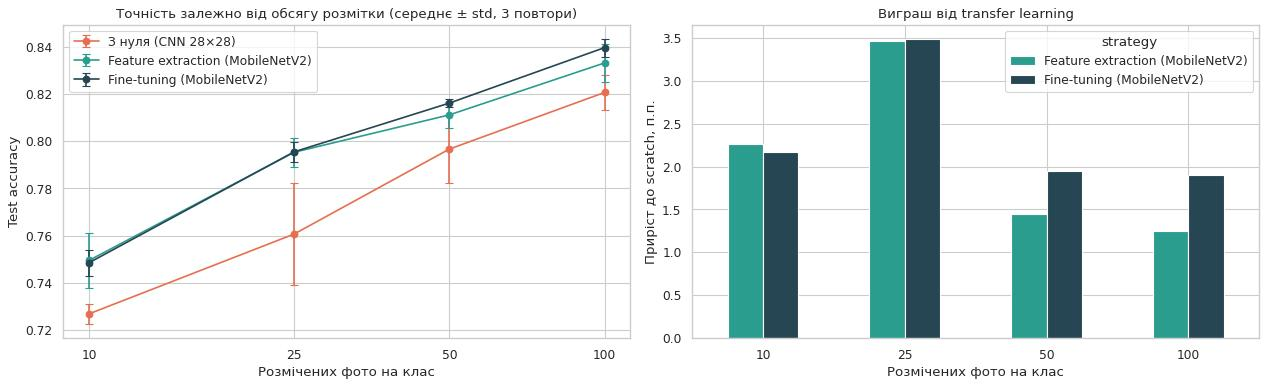

In [7]:
names = {"scratch": "З нуля (CNN 28×28)", "feature_extraction": "Feature extraction (MobileNetV2)", "finetune": "Fine-tuning (MobileNetV2)"}
agg = tl.groupby(["per_class", "strategy"])["test_acc"].agg(["mean", "std"]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for s, c in zip(names, ["#e76f51", "#2a9d8f", "#264653"]):
    d = agg[agg.strategy == s]
    axes[0].errorbar(d.per_class, d["mean"], yerr=d["std"], marker="o", capsize=4, label=names[s], color=c)
axes[0].set_xscale("log"); axes[0].set_xticks([10, 25, 50, 100]); axes[0].set_xticklabels(["10", "25", "50", "100"])
axes[0].set_xlabel("Розмічених фото на клас"); axes[0].set_ylabel("Test accuracy"); axes[0].legend()
axes[0].set_title("Точність залежно від обсягу розмітки (середнє ± std, 3 повтори)")
gain = agg.pivot(index="per_class", columns="strategy", values="mean")
(gain[["feature_extraction", "finetune"]].sub(gain["scratch"], axis=0) * 100).rename(columns=names).plot(
    kind="bar", ax=axes[1], rot=0, color=["#2a9d8f", "#264653"])
axes[1].axhline(0, color="black", lw=0.8); axes[1].set_xlabel("Розмічених фото на клас")
axes[1].set_ylabel("Приріст до scratch, п.п."); axes[1].set_title("Виграш від transfer learning")
plt.tight_layout(); plt.show()

## 1.5. Де саме допомагає перенесення (бюджет 25 фото на клас)

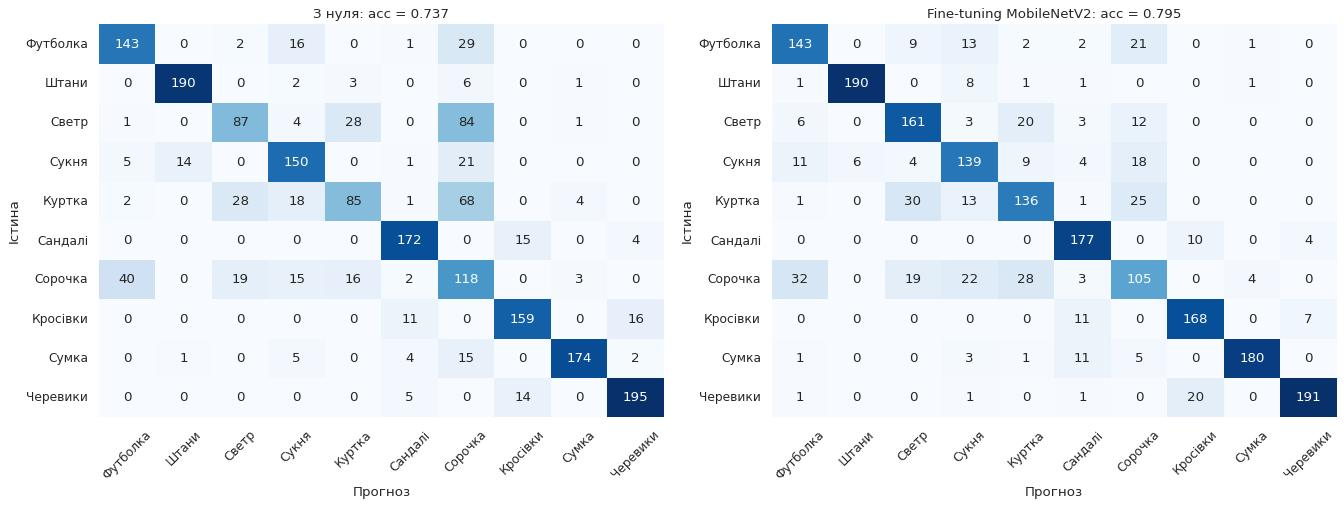

,scratch,finetune,різниця
Светр,0.424,0.785,0.361
Куртка,0.413,0.660,0.248
Кросівки,0.855,0.903,0.048
Сумка,0.866,0.896,0.030
Сандалі,0.901,0.927,0.026
Футболка,0.749,0.749,0.000
Штани,0.941,0.941,0.000
Черевики,0.911,0.893,-0.019
Сукня,0.785,0.728,-0.058
Сорочка,0.554,0.493,-0.061


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, key, t in [(axes[0], "scratch", "З нуля"), (axes[1], "finetune", "Fine-tuning MobileNetV2")]:
    p = keep[key]
    sns.heatmap(confusion_matrix(y[idx_test], p), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f"{t}: acc = {accuracy_score(y[idx_test], p):.3f}"); ax.set_xlabel("Прогноз"); ax.set_ylabel("Істина")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
rec = pd.DataFrame({k: [((keep[k] == c) & (y[idx_test] == c)).sum() / (y[idx_test] == c).sum() for c in range(10)] for k in keep}, index=CLASSES)
rec["різниця"] = rec["finetune"] - rec["scratch"]
rec.round(3).sort_values("різниця", ascending=False)

## 1.6. Використання моделі в проєкті (шаблон)
Для власних фото (наприклад, класифікації зразків техніки) застосовується той самий порядок дій. Змінюються лише розмір входу і джерело даних:
```python
base = keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False
train_ds = keras.utils.image_dataset_from_directory("data/train", image_size=(224, 224), batch_size=32)
inputs = keras.Input((224, 224, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = layers.GlobalAveragePooling2D()(base(x, training=False))
outputs = layers.Dense(len(train_ds.class_names), activation="softmax")(layers.Dropout(0.2)(x))
model = keras.Model(inputs, outputs)   # 1) навчити голову; 2) розморозити верхні блоки, lr 1e-5, дотренувати
```

# Висновки (частина 1)
1. **Модель з публічного репозиторію дала стабільний приріст на всіх бюджетах розмітки.** Feature extraction і fine-tuning MobileNetV2 (ImageNet) перевершили навчання з нуля на **1.2–3.5 п.п.**: при 10 фото на клас 0.750 проти 0.727, при 25 фото 0.796 проти 0.761. На бюджетах 25–50 фото результат transfer learning ще й стабільніший: розкид між повторами 0.002–0.006 проти 0.015–0.021 у scratch.
2. **Виграш найбільший, коли даних мало, і зменшується з їх ростом.** При 25 фото на клас перенесення дає +3.5 п.п., при 100 уже +1.2–1.9 п.п. З достатнім обсягом власних даних спеціалізована модель наздоганяє загальну.
3. **Feature extraction — найвигідніший варіант.** Точність майже як у fine-tuning (різниця ≤ 0.7 п.п.), а навчання голови займає ~7 s проти 22–43 s. Ознаки 10 000 зображень обчислюються один раз (≈ 30 s). Fine-tuning виправданий лише на більших бюджетах, де додає ще 0.5–0.7 п.п.
4. **Перенесення допомагає вибірково.** Найбільший виграш дістається класам, які відрізняються текстурою та формою: светр +36 п.п., куртка +25 п.п. На класах, схожих між собою (сорочка, сукня), fine-tuning трохи гірший. Частину якості забирає **зсув домену**: модель навчали на кольорових фото 224×224, а тут чорно-білі зображення 28×28, збільшені до 96×96.
5. **Робота з репозиторієм — це не лише `weights="imagenet"`.** Потрібні зафіксоване джерело (конкретний реліз), перевірка SHA-256, model card з описом вхідного формату й обмежень та узгодження передобробки. Без цього модель легко отримати «зламаною» або підміненою.